In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ResNet3D, ResNetBlock3D, GraphConvolution, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph, pm

print(jax.devices("gpu"))
print(jax.default_backend())

[cuda(id=0)]
gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0

# CAMELS

In [4]:
i_snapshots=range(1, 33+8, 8)

hydro_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Found matching catalogs
Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  20%|██        | 1/5 [00:01<00:06,  1.54s/it]

Found 368 duplicate gas particle IDs


finding unique gas particle indices:  40%|████      | 2/5 [00:07<00:12,  4.28s/it]

Found 4088 duplicate gas particle IDs


...

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 5/5 [00:25<00:00,  5.13s/it]


There are 15915410 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [01:06<00:00, 13.38s/it]

Could not stack h_poss
Could not stack h_masss
Could not stack h_lens
Could not stack h_ids


In [16]:
@nnx.jit(static_argnames=("loss_fn",))
def train_step(model, optimizer, loss_fn):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

losses = []

In [17]:
cosmo = hydro_dict["cosmo"]
scales = hydro_dict["scales"]

dm_poss = hydro_dict["dm_poss"]
dm_vels = hydro_dict["dm_vels"]

gas_poss = hydro_dict["gas_poss"]
gas_vels = hydro_dict["gas_vels"]

def solve_ode_diffrax(model):
    res = diffeqsolve(
            # terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gravity_model=model)),
            terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, pressure_model=model)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.02,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
    )

    res = res.ys

    return res

In [18]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([box_size] * 3),
            kmin=np.pi / box_size,
            dk=2 * np.pi / box_size,
        )
)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([box_size] * 3),
            kmin=np.pi / box_size,
            dk=2 * np.pi / box_size,
        )
)

# loss

### CAMELS ground truth

In [19]:
# per-particle reference
# ref_poss = jnp.stack(dm_poss, axis=0)
# ref_vels = jnp.stack(dm_vels, axis=0)

ref_poss = jnp.stack(gas_poss, axis=0)
ref_vels = jnp.stack(gas_vels, axis=0)


# field-level reference
ref_rhos = vcic_paint(jnp.zeros(mesh_shape), ref_poss)

# power spectrum reference
_, ref_cls = vpower_spectrum(ref_rhos)

# vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

In [20]:
# gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)
# dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)

# # per-particle reference
# ref_gas_pos = jnp.stack(gas_poss, axis=0)
# ref_gas_vel = jnp.stack(gas_vels, axis=0)

# # field-level reference
# n_rho_dm = vcic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"], 1)

# h_rho_dm = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"], dm_mass)
# h_rho_gas = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"], gas_mass)

# # power spectrum reference
# _, n_cl_dm = vpower_spectrum(n_rho_dm)

# _, h_cl_dm = vpower_spectrum(h_rho_dm)
# _, h_cl_gas = vpower_spectrum(h_rho_gas)

# # vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

### particle-level

In [21]:
def particle_loss_fn(model, eps=1e-8):
    res = solve_ode_diffrax(model)
    # dark matter
    # poss = res[0]
    # vels = res[1]

    # gas
    poss = res[2]
    vels = res[3]

    delta_poss = ((poss - ref_poss + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_poss**2, axis=-1)
    pos_loss = jnp.mean(pos_loss)
    
    res_rhos = vcic_paint(jnp.zeros(mesh_shape), poss)
    kbins, res_cls = vpower_spectrum(res_rhos)

    k = kbins[0]
    k_min, k_cutoff = k[0], k[int(0.2*len(k))]
    k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

    cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)
    cl_loss = jnp.mean(cl_loss)

    return pos_loss + 0.1 * cl_loss


### field-level

In [22]:
def field_loss_fn(model, architecture):
    pass

# architecture

In [23]:
model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))
# model = nn.NeuralSplineFourierFilterNNX(n_knots=16, d_latent=64, rngs=nnx.Rngs(0))

# training

In [24]:
total_steps = 1000
# learning_rate = 1e-3
learning_rate = optax.cosine_decay_schedule(
    init_value=1e-3, 
    decay_steps=total_steps, 
    alpha=0.1
)
clip_norm = 1

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
loss_fn = particle_loss_fn
# loss_fn = lambda model: field_loss_fn(model, architecture)

  0%|          | 0/1000 [00:00<?, ?it/s]

dark matter and gas
Using Denise-style learned pressure force
dark matter and gas
Using Denise-style learned pressure force
dark matter and gas
Using Denise-style learned pressure force


2025-04-17 17:49:07.597587: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %negate.117 = f32[5,262144,3]{2,1,0} negate(f32[5,262144,3]{2,1,0} %constant.185)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-04-17 17:49:09.550979: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 2.95347275s
Constant folding an instruction is taking > 1s:

  %negate.117 = f32[5,262144,3]{2,1,0} negate(f32[5,262144,3]{2,1,0} %constant.185)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some g

[None]

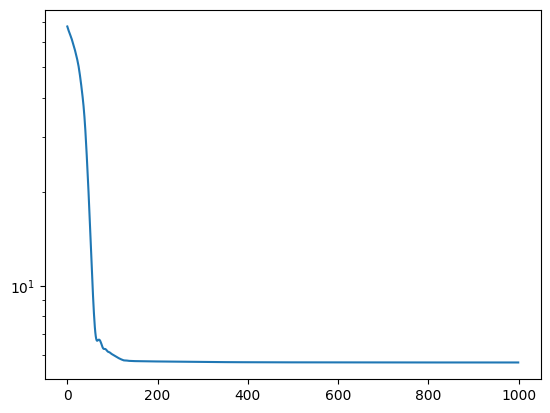

In [26]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss = train_step(model, optimizer, loss_fn)

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

### checkpointing

In [ ]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim_new_2.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [ ]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [ ]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

In [29]:
def compare_sims(hydro_dict):
    scales = hydro_dict["scales"]
    
    dm_poss = hydro_dict["dm_poss"]
    dm_vels = hydro_dict["dm_vels"]
    
    gas_poss = hydro_dict["gas_poss"]
    gas_vels = hydro_dict["gas_vels"]
    
    og_ode = hpm.get_hpm_network_ode_fn(
        mesh_per_dim, cosmo, gravity_model=None, pressure_model=None, integrator_type="diffrax"
    )
    
    og_res = diffeqsolve(
            terms=ODETerm(og_ode),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.01,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
    )
    
    og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

    nn_ode = hpm.get_hpm_network_ode_fn(
        # mesh_per_dim, cosmo, gravity_model=model, pressure_model=None, integrator_type="diffrax"
        mesh_per_dim, cosmo, gravity_model=None, pressure_model=model, integrator_type="diffrax"
    )
    
    nn_res = diffeqsolve(
            terms=ODETerm(nn_ode),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.01,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
    )
    
    nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys

    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([dm_poss, og_dm_poss, nn_dm_poss], axis=0), 
        title="dark matter",
        col_titles=["CAMELS", "pm", "pm + network"],
        include_pk=True,
        include_reference=True,
    )

    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0), 
        title="gas",
        col_titles=["CAMELS", "pm", "pm + network"],
        include_pk=True,
        include_reference=True,
    )

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using Denise-style learned pressure force
dark matter and gas
Using Denise-style learned pressure force
dark matter and gas
Using Denise-style learned pressure force


100%|██████████| 5/5 [00:09<00:00,  1.90s/it]


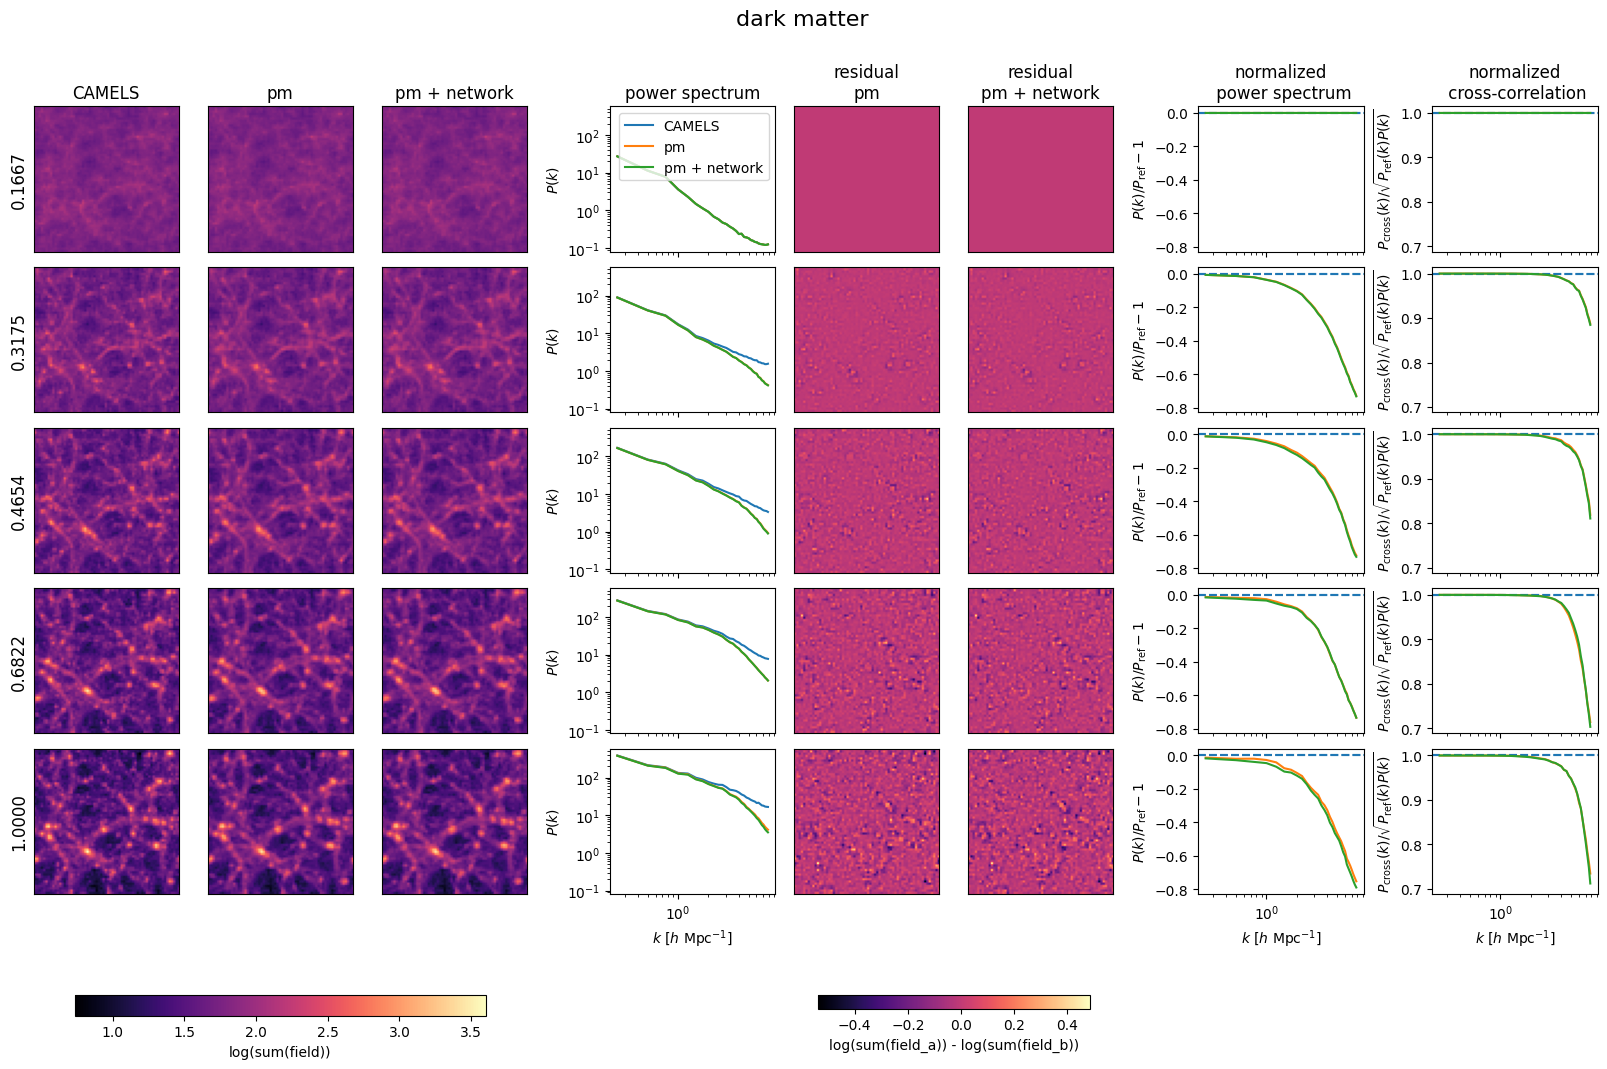

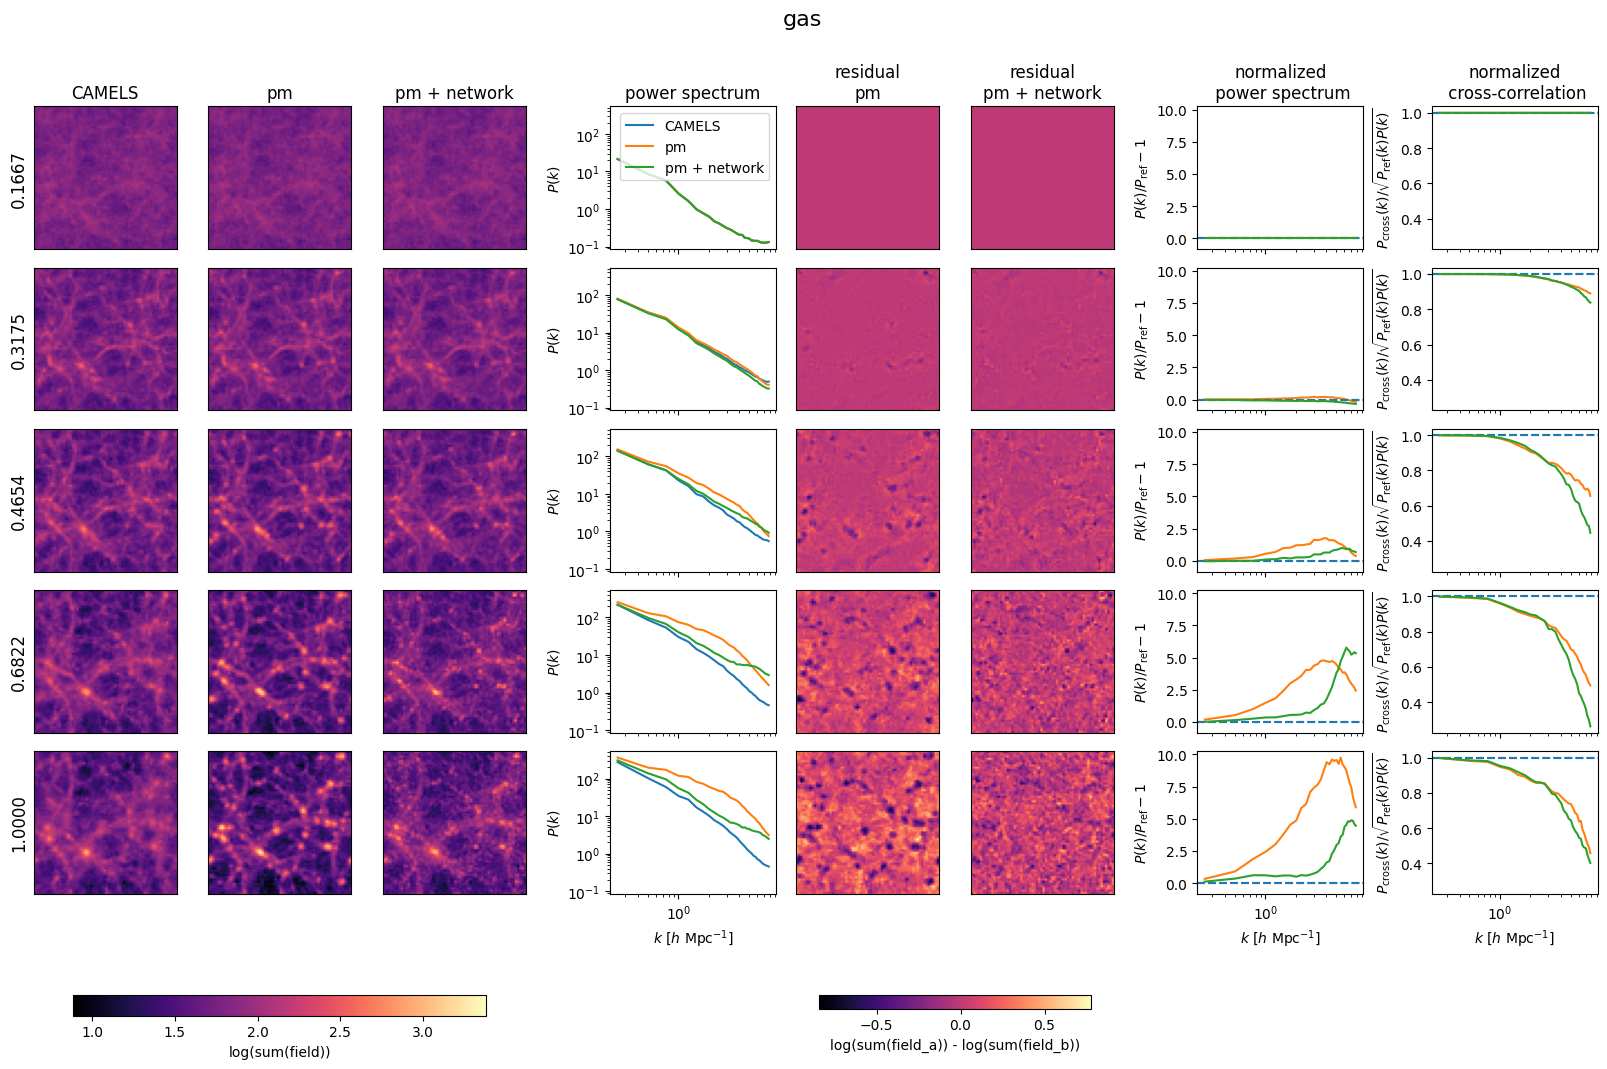

In [30]:
compare_sims(hydro_dict)

In [ ]:
vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

In [ ]:
compare_sims(vali_dict)

# trash